# Day 7 — Extension Tasks: Chunking Strategies (Steps + Code)

This notebook contains step-by-step tasks (1–6) you can run after the live demo.
Each task is self-contained: a short description followed by runnable Python code.

## Task 1 — Tune Chunk Size and Overlap (Easy): Steps
Re-run Strategy 3 (RecursiveCharacterTextSplitter) across chunk_size values [100,300,600]
and chunk_overlap values [0,50,150]. For each combination, print the chunk count and show 2 sample chunks.
Run this cell to get a quick matrix of results.

In [2]:
from langchain_text_splitters import RecursiveCharacterTextSplitter


def run_recursive_grid(text, chunk_sizes=(100, 300, 600), overlaps=(0, 50, 150), show_per_combo=2):
    results = []
    for cs in chunk_sizes:
        for ov in overlaps:
            if ov >= cs:
                continue
            splitter = RecursiveCharacterTextSplitter(
                chunk_size=cs,
                chunk_overlap=ov,
                separators=["\n\n", "\n", " ", ""]
            )
            chunks = splitter.split_text(text)
            sample = chunks[:show_per_combo] if len(chunks) > 0 else []
            results.append({'chunk_size': cs, 'overlap': ov, 'n_chunks': len(chunks), 'sample': sample})
    return results

# Run on sample_document from the demo; if not available, paste your text into 'text' variable.
try:
    text = sample_document
except NameError:
    text = ''  # replace with your document text

grid = run_recursive_grid(text)
for r in grid:
    print(f"chunk_size={r['chunk_size']}, overlap={r['overlap']} -> {r['n_chunks']} chunks")
    for i, c in enumerate(r['sample']):
        print(f"  sample {i + 1}: {c[:200].replace(chr(10), ' ')}...")
    print()

c:\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


chunk_size=100, overlap=0 -> 0 chunks

chunk_size=100, overlap=50 -> 0 chunks

chunk_size=300, overlap=0 -> 0 chunks

chunk_size=300, overlap=50 -> 0 chunks

chunk_size=300, overlap=150 -> 0 chunks

chunk_size=600, overlap=0 -> 0 chunks

chunk_size=600, overlap=50 -> 0 chunks

chunk_size=600, overlap=150 -> 0 chunks



---
## Task 2 — Structure-Aware Splitter for Numbered Clauses (Medium): Steps
Write a splitter that splits on clause numbering patterns (e.g., '^1.', '^1.1', 'Section 1.').
Compare its output to the Recursive splitter on the same text.

In [3]:
import re
from typing import List


def numbered_clause_splitter(text: str) -> List[str]:
    """Split a document on lines that start with a clause number like '1.' or '1.1' or 'Section 1.'
    This is a simple heuristic splitter — tune the regex for your document's numbering style.
    """
    txt = text.replace('\r\n', '\n').replace('\r', '\n')
    pattern = r'(?m)(?=^(?:\d+(?:\.\d+)*\.|Section\s+\d+\.))'
    parts = re.split(pattern, txt)
    parts = [p.strip() for p in parts if p.strip()]
    return parts


# Example usage: replace 'numbered_text' with your contract/policy text that uses numbered clauses.
try:
    numbered_text = sample_document  # demo's sample has '4.1' style headings and will work as an example
except NameError:
    numbered_text = ''

num_chunks = numbered_clause_splitter(numbered_text)
print(f'Produced {len(num_chunks)} numbered-clause chunks')
for i, c in enumerate(num_chunks):
    print(f'--- Clause {i + 1} ({len(c)} chars) ---')
    print(c[:400])
    print()

# Compare to recursive splitter (Strategy 3) if available
try:
    from langchain_text_splitters import RecursiveCharacterTextSplitter
    rec = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50)
    rec_chunks = rec.split_text(numbered_text)
    print('Recursive produced', len(rec_chunks), 'chunks')
except Exception as e:
    print('Recursive splitter not available or failed:', e)

Produced 0 numbered-clause chunks
Recursive produced 0 chunks


---
## Task 3 — Measure Retrieval Quality (Medium–Hard): Steps
This task requires the RAG pipeline from Demo 1.
1. Re-index the same KB with two chunking strategies.
2. Run the same test queries and record top-3 retrieved chunks.
3. Compare whether the correct chunk appears in top-3 and whether the faithfulness check passes.

The code below is a template — adapt it to your project's indexing and retrieval functions.

In [5]:
# TEMPLATE: adapt these functions to your Demo1 pipeline's API
def reindex_with_chunks(chunk_texts, index_name):
    "Recreate an index from a list of chunk strings. Implement using your embedding + vector DB code."
    raise NotImplementedError('Implement reindex_with_chunks using your Demo1 indexing utilities')

def run_queries_against_index(queries, index_name, top_k=3):
    "Return a list of retrieval results for each query: [(q, [top_doc_texts])...]"
    raise NotImplementedError('Implement run_queries_against_index to call your retriever')

# Example workflow (pseudocode):
# 1) Create chunks using strategy A and B
# chunks_a = strategy_a_split(documents)
# chunks_b = strategy_b_split(documents)
# 2) reindex_with_chunks(chunks_a, 'index_a')
#    reindex_with_chunks(chunks_b, 'index_b')
# 3) queries = ['What is the deductible for collision?', ...]
#    results_a = run_queries_against_index(queries, 'index_a')
#    results_b = run_queries_against_index(queries, 'index_b')
# 4) Compare top-3 retrievals and run your Demo1 faithfulness check on the retrieved contexts.

print('Task 3 provides a template — plug into Demo1 pipeline and run locally.')

Task 3 provides a template — plug into Demo1 pipeline and run locally.


---
## Task 4 — Tune the Semantic Chunking Threshold (Medium): Steps
Try `similarity_drop_threshold` values [0.1, 0.25, 0.4], compute chunk counts, and plot how chunk count changes.

Threshold -> #chunks
0.1 -> 1
0.25 -> 1
0.4 -> 1


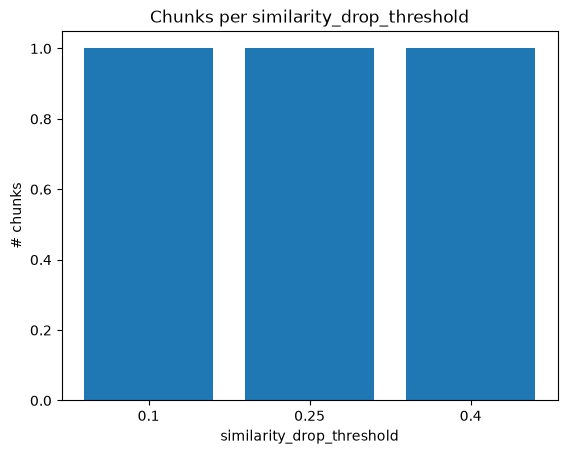

In [8]:
import re
import numpy as np
import matplotlib.pyplot as plt


def semantic_chunk_counts_for_thresholds(text, thresholds=(0.1, 0.25, 0.4), fallback_to_tfidf=True):
    """Compute chunk counts using sentence embeddings when available, else a local TF-IDF fallback."""
    clean = re.sub(r'\n+', ' ', text or '').strip()
    sentences = re.split(r'(?<=[.!?])\s+', clean)
    sentences = [s.strip() for s in sentences if s.strip()]

    if len(sentences) < 2:
        return {t: 1 for t in thresholds}

    try:
        from sentence_transformers import SentenceTransformer
        embedder = SentenceTransformer('all-MiniLM-L6-v2')
        embeddings = embedder.encode(sentences, normalize_embeddings=True)
        vectors = np.asarray(embeddings)
        mode = 'sentence-transformers'
    except Exception as e:
        if not fallback_to_tfidf:
            raise
        print(f"Model download failed ({e}). Falling back to TF-IDF similarity.")
        from sklearn.feature_extraction.text import TfidfVectorizer
        vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
        X = vectorizer.fit_transform(sentences)
        vectors = X.toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        vectors = vectors / norms
        mode = 'tf-idf'

    sims = []
    for i in range(len(vectors) - 1):
        a = np.asarray(vectors[i], dtype=float)
        b = np.asarray(vectors[i + 1], dtype=float)
        denom = np.linalg.norm(a) * np.linalg.norm(b)
        sim = float(np.dot(a, b) / denom) if denom else 1.0
        sims.append(sim)

    counts = {}
    for t in thresholds:
        chunks = []
        current = [sentences[0]]
        for i, sim in enumerate(sims):
            if sim < (1.0 - t):
                chunks.append(' '.join(current))
                current = [sentences[i + 1]]
            else:
                current.append(sentences[i + 1])
        chunks.append(' '.join(current))
        counts[t] = len(chunks)

    print(f"Semantic chunking using: {mode}")
    return counts


try:
    text = sample_document
except NameError:
    text = ''

counts = semantic_chunk_counts_for_thresholds(text)
print('Threshold -> #chunks')
for k, v in counts.items():
    print(k, '->', v)

plt.bar([str(k) for k in counts.keys()], counts.values())
plt.title('Chunks per similarity_drop_threshold')
plt.xlabel('similarity_drop_threshold')
plt.ylabel('# chunks')
plt.show()

---
## Task 5 — Chunk a Real PDF (Hard): Steps
Install `pypdf` or `pdfplumber`, extract text from the PDF, then run the chunkers above.
This cell extracts text with `pypdf` and runs the recursive + structure-aware hybrid approach.

In [10]:
# pip install pypdf if needed
try:
    from pypdf import PdfReader
except Exception:
    print('Install pypdf: pip install pypdf')

def extract_text_from_pdf(path):
    from pypdf import PdfReader
    reader = PdfReader(path)
    texts = []
    for p in reader.pages:
        texts.append(p.extract_text() or '')
    return '\n\n'.join(texts)

# Example usage: replace 'sample.pdf' with your file path.
pdf_path = 'sample.pdf'
# pdf_text = extract_text_from_pdf(pdf_path)
# Then run structure-aware or recursive splitting on pdf_text.
print('Define pdf_path and uncomment extraction to run on a real PDF.')

Define pdf_path and uncomment extraction to run on a real PDF.


---
## Task 6 — Cost & Latency Back-of-Envelope (Easy): Steps
Estimate number of chunks for 10,000 pages given average chunk lengths and compute embedding call counts.
This cell provides a quick estimator you can adapt with measured averages from your corpus.

In [12]:
def estimate_costs(pages=10000, chars_per_page=3000, avg_chunk_length_chars=None):
    # avg_chunk_length_chars: dict mapping strategy->avg_chunk_chars
    if avg_chunk_length_chars is None:
        avg_chunk_length_chars = {
            'Fixed-200': 200,
            'Recursive': 350,
            'Structure': 1200,
            'Semantic': 300
        }
    total_chars = pages * chars_per_page
    estimates = {}
    for name, avg in avg_chunk_length_chars.items():
        n_chunks = int(total_chars / avg)
        # assume one embedding call per chunk (approx)
        n_embedding_calls = n_chunks
        estimates[name] = {'n_chunks': n_chunks, 'n_embedding_calls': n_embedding_calls}
    return estimates

est = estimate_costs()
for k, v in est.items():
    print(f"{k}: ~{v['n_chunks']:,} chunks, ~{v['n_embedding_calls']:,} embedding calls")

print("Which is cheapest to index depends on avg chunk length; to re-index after a change, a strategy that localizes changes into fewer chunks (structure-aware) is often cheaper.")

Fixed-200: ~150,000 chunks, ~150,000 embedding calls
Recursive: ~85,714 chunks, ~85,714 embedding calls
Structure: ~25,000 chunks, ~25,000 embedding calls
Semantic: ~100,000 chunks, ~100,000 embedding calls
Which is cheapest to index depends on avg chunk length; to re-index after a change, a strategy that localizes changes into fewer chunks (structure-aware) is often cheaper.
